In [ ]:
!pip install cplex

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 MB 14.7 MB/s eta 0:00:00


Generate random graph (global graph)



In [ ]:
import random
import numpy as np
import cplex
import networkx as nx
import matplotlib.pyplot as plt

def generate_graph(num_nodes, num_edges, weight_range=(1, 10)):
    # Generate random graph with weights
    graph = []
    edges = set()

    # Generate unique edges
    while len(edges) < num_edges:
        source = random.randint(1, num_nodes)
        target = random.randint(1, num_nodes)

        if source != target:
            edge = (source, target)
            edges.add(edge)

    # Assign random weights to the edges
    for edge in edges:
        weight = random.randint(weight_range[0], weight_range[1])
        graph.append((edge[0], edge[1], weight))

    return graph

def generate_agents(num_nodes, num_agents):
    # Generate a subset of nodes as agents
    agents = random.sample(range(1, num_nodes + 1), num_agents)
    return agents

def save_graph_instance(graph, agents, filepath):
    with open(filepath, 'w') as file:
        file.write("Edges:\n")
        for edge in graph:
            file.write(f'{edge[0]} {edge[1]} {edge[2]}\n')

        file.write("\nAgents:\n")
        for agent in agents:
            file.write(f'{agent}\n')

def display_agents(graph, agents):
    # Display which nodes are agents
    print("Agents:")
    for node in graph.nodes:
        if node in agents:
            print(f"Node {node} is an agent.")

def display_adjacency_matrix(graph):
    # Display the graph adjacency matrix
    adjacency_matrix = nx.to_numpy_array(graph)
    print("Adjacency Matrix:")
    print(adjacency_matrix)

# Get user input
num_nodes = int(input("Enter the number of nodes: "))
num_edges = int(input("Enter the number of edges: "))
weight_range = tuple(map(int, input("Enter the weight range (min max): ").split()))
num_agents = int(input("Enter the number of agents: "))

# Generate graph and agents
graph = nx.DiGraph()
graph.add_weighted_edges_from(generate_graph(num_nodes, num_edges, weight_range))
agents = generate_agents(num_nodes, num_agents)

# Save the graph instance to a .dat file
filepath = 'graph_instance.dat'
save_graph_instance(graph.edges.data('weight'), agents, filepath)

print(f"Graph instance saved to '{filepath}'.")

# Display agents and adjacency matrix
display_agents(graph, agents)
display_adjacency_matrix(graph)


Enter the number of nodes: 6
Enter the number of edges: 9
Enter the weight range (min max): 1 3
Enter the number of agents: 1
Graph instance saved to 'graph_instance.dat'.
Agents:
Node 6 is an agent.
Adjacency Matrix:
[[0. 3. 1. 0. 2. 3.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 3. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 3. 0. 0.]]


Draw the graph

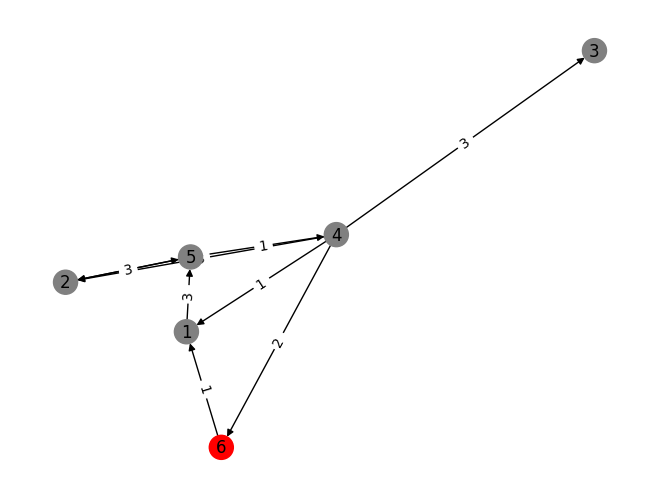

In [ ]:
# Draw the graph
pos = nx.spring_layout(graph)#, k=0.20, iterations=20
node_colors = ['red' if node in agents else 'gray' for node in graph.nodes]
edge_labels = nx.get_edge_attributes(graph, 'weight')
nx.draw(graph, pos, with_labels=True, node_color=node_colors)
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
plt.show()

Generate a random s-t graph


In [ ]:
import random
import numpy as np
import cplex
import networkx as nx
import matplotlib.pyplot as plt

def generate_st_graph(num_nodes, num_edges, weight_range=(1, 10)):
    # Generate random s-t graph with weights
    graph = nx.DiGraph()
    source = 1
    sink = num_nodes
    graph.add_node(source)  # Add source node
    graph.add_node(sink)  # Add sink node

    # Generate a connected directed acyclic graph (DAG) with random edges
    for node in range(source, sink):
        graph.add_edge(node, node+1)

    # Randomly add additional edges
    existing_edges = set(graph.edges)
    num_existing_edges = len(existing_edges)
    while num_existing_edges < num_edges:
        src = random.randint(source, sink-1)
        tgt = random.randint(src+1, sink)
        edge = (src, tgt)
        if edge not in existing_edges:
            graph.add_edge(src, tgt)
            existing_edges.add(edge)
            num_existing_edges += 1

    # Assign random weights to the edges
    for edge in graph.edges:
        weight = random.randint(weight_range[0], weight_range[1])
        graph[edge[0]][edge[1]]['weight'] = weight

    return graph

def generate_agents(num_nodes, num_agents):
    # Generate a subset of nodes as agents
    agents = random.sample(range(2, num_nodes), num_agents)  # Exclude the source and sink nodes
    return agents

def save_graph_instance(graph, agents, filepath):
    with open(filepath, 'w') as file:
        file.write("Source: 1\n")
        file.write(f"Sink: {num_nodes}\n")
        file.write("\nEdges:\n")
        for edge in graph.edges:
            file.write(f'{edge[0]} {edge[1]} {graph[edge[0]][edge[1]]["weight"]}\n')

        file.write("\nAgents:\n")
        for agent in agents:
            file.write(f'{agent}\n')

def display_agents(graph, agents):
    # Display which nodes are agents
    print("Agents:")
    for node in graph.nodes:
        if node in agents:
            print(f"Node {node} is an agent.")

def display_adjacency_matrix(graph):
    # Display the graph adjacency matrix
    adjacency_matrix = nx.to_numpy_array(graph)
    print("Adjacency Matrix:")
    print(adjacency_matrix)

# Get user input
num_nodes = int(input("Enter the number of nodes: "))
num_edges = int(input("Enter the number of edges: "))
weight_range = tuple(map(int, input("Enter the weight range (min max): ").split()))
num_agents = int(input("Enter the number of agents: "))

# Generate graph and agents
graph = generate_st_graph(num_nodes, num_edges, weight_range)
agents = generate_agents(num_nodes, num_agents)

# Save the graph instance to a .dat file
filepath = 'stgraph_instance.dat'
save_graph_instance(graph, agents, filepath)

print(f"Graph instance saved to '{filepath}'.")

# Display agents and adjacency matrix
display_agents(graph, agents)
display_adjacency_matrix(graph)

Enter the number of nodes: 6
Enter the number of edges: 9
Enter the weight range (min max): 1 3
Enter the number of agents: 1
Graph instance saved to 'stgraph_instance.dat'.
Agents:
Node 3 is an agent.
Adjacency Matrix:
[[0. 0. 2. 2. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 3. 0. 2.]
 [0. 0. 0. 0. 3. 0.]
 [0. 0. 0. 0. 0. 3.]
 [0. 1. 0. 0. 0. 0.]]


Draw the s-t graph ( yellow -> source ; blue -> sink )

In [ ]:
# Save the graph instance to a .dat file
filepath = 'stgraph_instance2.dat'
save_graph_instance(graph, agents, filepath)

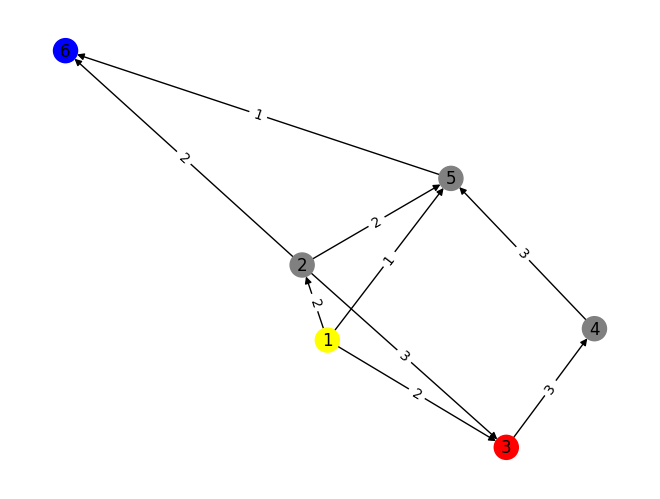

In [ ]:
# Draw the graph
pos = nx.spring_layout(graph)
node_colors = ['yellow' if node == 1 else 'blue' if node == num_nodes else 'red' if node in agents else 'gray' for node in graph.nodes]
edge_labels = nx.get_edge_attributes(graph, 'weight')
nx.draw(graph, pos, with_labels=True, node_color=node_colors)
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
plt.show()

Solve the min cut problem of an s-t graph

In [ ]:
import cplex

# Load graph instance from the .dat file
def load_graph_instance(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

        # Extract the number of nodes
        num_nodes = int(lines[1].split()[1])

        # Find the line index where the edges start
        start_index = lines.index("Edges:\n") + 1

        # Extract the edges from the lines
        edges = []
        for line in lines[start_index:]:
            if line == "\n":
                break
            u, v, weight = map(int, line.split())
            edges.append((u, v, weight))

        return num_nodes, edges


# Define the LP model
def create_lp_model(num_nodes, edges):
    model = cplex.Cplex()
    model.set_problem_name("MinCutLP")

    # Decision variables
    d = model.variables.add(names=["d_{}_{}".format(u, v) for u, v, _ in edges], types=[model.variables.type.binary] * len(edges))
    p = model.variables.add(names=["p_{}".format(u) for u in range(1, num_nodes+1)], types=[model.variables.type.binary] * num_nodes)

    # Objective function
    costs = [weight for _, _, weight in edges]
    model.objective.set_sense(model.objective.sense.minimize)
    model.objective.set_linear([(d[i], costs[i]) for i in range(len(edges))])

    # Constraints
    for i, (u, v, _) in enumerate(edges):
        model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=[d[i], p[u-1], p[v-1]], val=[1.0, -1.0, 1.0])], senses=["G"], rhs=[0.0])

    model.linear_constraints.add(lin_expr=[[[p[0]], [1.0]]], senses=["E"], rhs=[1.0])
    model.linear_constraints.add(lin_expr=[[[p[num_nodes-1]], [1.0]]], senses=["E"], rhs=[0.0])

    return model

# Solve the LP model
def solve_lp_model(model, edges):
    model.solve()

    # Get solution
    solution = model.solution

    # Print solution
    print("Solution status:", solution.get_status())
    print("Objective value:", solution.get_objective_value())
    print("Cut edges:")
    for i in range(len(edges)):
        if solution.get_values("d_{}_{}".format(edges[i][0], edges[i][1])) >= 0.5:
            print("Edge ({}, {})".format(edges[i][0], edges[i][1]))

# Load graph instance from the .dat file
num_nodes, edges = load_graph_instance("stgraph_instance.dat")
print(load_graph_instance("stgraph_instance.dat"))
# Create the LP model
model = create_lp_model(num_nodes, edges)

# Solve the LP model
solve_lp_model(model, edges)


(6, [(1, 2, 2), (1, 5, 1), (1, 3, 2), (2, 3, 3), (2, 6, 2), (2, 5, 2), (3, 4, 3), (4, 5, 3), (5, 6, 1)])
Version identifier: 22.1.1.0 | 2023-02-11 | 22d6266e5
CPXPARAM_Read_DataCheck                          1
Tried aggregator 2 times.
MIP Presolve eliminated 8 rows and 10 columns.
Aggregator did 3 substitutions.
All rows and columns eliminated.
Presolve time = 0.00 sec. (0.02 ticks)

Root node processing (before b&c):
  Real time             =    0.01 sec. (0.02 ticks)
Parallel b&c, 2 threads:
  Real time             =    0.00 sec. (0.00 ticks)
  Sync time (average)   =    0.00 sec.
  Wait time (average)   =    0.00 sec.
                          ------------
Total (root+branch&cut) =    0.01 sec. (0.02 ticks)
Solution status: 101
Objective value: 3.0
Cut edges:
Edge (1, 2)
Edge (5, 6)


Solving the min cut problem with agents

Add edges:

In [ ]:
def load_graph_instance(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

        # Extract the number of nodes
        num_nodes = int(lines[1].split()[1])

        # Find the line index where the edges start
        start_index = lines.index("Edges:\n") + 1

        # Extract the edges from the lines
        edges = []
        for line in lines[start_index:]:
            if line == "\n":
                break
            u, v, weight = map(int, line.split())
            edges.append((u, v, weight))

        # Find the line index where the agents start
        agents_start_index = lines.index("Agents:\n") + 1

        # Extract the agents from the lines
        agents = []
        for line in lines[agents_start_index:]:
            if line == "\n":
                break
            agent = int(line)
            agents.append(agent)

        return num_nodes, edges, agents

def add_new_edges(num_nodes, edges, agents):
    print(num_nodes)
    print(edges)
    print(agents)
    existing_edges = {(u, v) for u, v, _ in edges}
    print(existing_edges)
    new_edges = []

    for agent in agents:
        for node in range(1, num_nodes + 1):
          if (node != agent):
            if (agent, node) in existing_edges and (node, agent) not in existing_edges:
                new_edges.append((node, agent, 0))
            if (agent, node) not in existing_edges and (node, agent) in existing_edges:
                new_edges.append((agent, node, 0))
            if (agent, node) not in existing_edges and (node, agent) not in existing_edges:
                new_edges.append((agent, node, 0))
                new_edges.append((node, agent, 0))

    return edges + new_edges

# Example usage
num_nodes, edges, agents = load_graph_instance("stgraph_instance.dat")

new_edges = add_new_edges(num_nodes, edges, agents)
print("Updated edges:", new_edges)


6
[(1, 2, 2), (1, 5, 1), (1, 3, 2), (2, 3, 3), (2, 6, 2), (2, 5, 2), (3, 4, 3), (4, 5, 3), (5, 6, 1)]
[3]
{(1, 2), (3, 4), (1, 5), (2, 3), (4, 5), (2, 6), (5, 6), (2, 5), (1, 3)}
Updated edges: [(1, 2, 2), (1, 5, 1), (1, 3, 2), (2, 3, 3), (2, 6, 2), (2, 5, 2), (3, 4, 3), (4, 5, 3), (5, 6, 1), (3, 1, 0), (3, 2, 0), (4, 3, 0), (3, 5, 0), (5, 3, 0), (3, 6, 0), (6, 3, 0)]


In [ ]:
import cplex

# Load graph instance from the .dat file
def load_graph_instance(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

        # Extract the number of nodes
        num_nodes = int(lines[1].split()[1])

        # Find the line index where the edges start
        start_index = lines.index("Edges:\n") + 1

        # Extract the edges from the lines
        edges = []
        for line in lines[start_index:]:
            if line == "\n":
                break
            u, v, weight = map(int, line.split())
            edges.append((u, v, weight))

        return num_nodes, edges


# Define the LP model
def create_lp_model(num_nodes, edges):
    model = cplex.Cplex()
    model.set_problem_name("MinCutLP")

    # Decision variables
    d = model.variables.add(names=["d_{}_{}".format(u, v) for u, v, _ in edges], types=[model.variables.type.binary] * len(edges))
    p = model.variables.add(names=["p_{}".format(u) for u in range(1, num_nodes+1)], types=[model.variables.type.binary] * num_nodes)
    k = model.variables.add(names=["k_{}".format(u) for u in range(len(new_edges+edges))], types=[model.variables.type.binary] * len(new_edges+edges))
    # Objective function
    costs = [weight for _, _, weight in edges]
    model.objective.set_sense(model.objective.sense.minimize)
    model.objective.set_linear([(d[i], costs[i]) for i in range(len(edges))])

    # Constraints
    for i, (u, v, _) in enumerate(edges):
        model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=[d[i], p[u-1], p[v-1]], val=[1.0, -1.0, 1.0])], senses=["G"], rhs=[0.0])

    model.linear_constraints.add(lin_expr=[[[p[0]], [1.0]]], senses=["E"], rhs=[1.0])
    model.linear_constraints.add(lin_expr=[[[p[num_nodes-1]], [1.0]]], senses=["E"], rhs=[0.0])

    # Additional constraints for outgoing edges of agents
    # Constraint for agent outgoing edges
    for agent in agents:
      outgoing_edges = [(u, v) for u, v, _ in edges + new_edges if u == agent]
      k_indices = [i for i, (u, v, _) in enumerate(edges + new_edges) if u == agent]
      lin_expr = [cplex.SparsePair(ind=[k[i] for i in k_indices], val=[1.0] * len(outgoing_edges))]
    model.linear_constraints.add(lin_expr=lin_expr, senses=["L"], rhs=[num_nodes / 2])

    # Constraint for agent incoming edges
    for agent in agents:
      incoming_edges = [(u, v) for u, v, _ in edges + new_edges if v == agent]
    k_indices = [i for i, (u, v, _) in enumerate(edges + new_edges) if v == agent]
    lin_expr = [cplex.SparsePair(ind=[k[i] for i in k_indices], val=[1.0] * len(incoming_edges))]
    model.linear_constraints.add(lin_expr=lin_expr, senses=["L"], rhs=[num_nodes / 2])


    return model

# Solve the LP model
def solve_lp_model(model, edges):
    model.solve()

    # Get solution
    solution = model.solution

    # Print solution
    print("Solution status:", solution.get_status())
    print("Objective value:", solution.get_objective_value())
    print("Cut edges:")
    for i in range(len(edges)):
        if solution.get_values("d_{}_{}".format(edges[i][0], edges[i][1])) >= 0.5:
            print("Edge ({}, {})".format(edges[i][0], edges[i][1]))

# Load graph instance from the .dat file
num_nodes, edges = load_graph_instance("stgraph_instance.dat")
print(load_graph_instance("stgraph_instance.dat"))
# Create the LP model
model = create_lp_model(num_nodes, edges)

# Solve the LP model
solve_lp_model(model, edges)


(6, [(1, 2, 2), (1, 5, 1), (1, 3, 2), (2, 3, 3), (2, 6, 2), (2, 5, 2), (3, 4, 3), (4, 5, 3), (5, 6, 1)])
Version identifier: 22.1.1.0 | 2023-02-11 | 22d6266e5
CPXPARAM_Read_DataCheck                          1
Tried aggregator 2 times.
MIP Presolve eliminated 10 rows and 35 columns.
Aggregator did 3 substitutions.
All rows and columns eliminated.
Presolve time = 0.01 sec. (0.03 ticks)

Root node processing (before b&c):
  Real time             =    0.01 sec. (0.03 ticks)
Parallel b&c, 2 threads:
  Real time             =    0.00 sec. (0.00 ticks)
  Sync time (average)   =    0.00 sec.
  Wait time (average)   =    0.00 sec.
                          ------------
Total (root+branch&cut) =    0.01 sec. (0.03 ticks)
Solution status: 101
Objective value: 3.0
Cut edges:
Edge (1, 2)
Edge (5, 6)


In [ ]:
import cplex

# Load graph instance from the .dat file
def load_graph_instance(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

        # Extract the number of nodes
        num_nodes = int(lines[1].split()[1])

        # Find the line index where the edges start
        start_index = lines.index("Edges:\n") + 1

        # Extract the edges from the lines
        edges = []
        for line in lines[start_index:]:
            if line == "\n":
                break
            u, v, weight = map(int, line.split())
            edges.append((u, v, weight))

        return num_nodes, edges


# Define the LP model
def create_lp_model(num_nodes, edges):
    model = cplex.Cplex()
    model.set_problem_name("MinCutLP")

    # Decision variables
    d = model.variables.add(names=["d_{}_{}".format(u, v) for u, v, _ in edges], types=[model.variables.type.binary] * len(edges))
    p = model.variables.add(names=["p_{}".format(u) for u in range(1, num_nodes+1)], types=[model.variables.type.binary] * num_nodes)
    k = model.variables.add(names=["k_{}_{}".format(u, v) for u, v, _ in (new_edges+edges)], types=[model.variables.type.binary] * len(new_edges+edges))
    # Objective function
    costs = [weight for _, _, weight in edges]
    model.objective.set_sense(model.objective.sense.minimize)
    model.objective.set_linear([(d[i], costs[i]) for i in range(len(edges))])

    # Constraints

    for i, (u, v, _) in enumerate(edges):
        model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=[d[i], p[u-1], p[v-1]], val=[1.0, -1.0, 1.0])], senses=["G"], rhs=[0.0])

    model.linear_constraints.add(lin_expr=[[[p[0]], [1.0]]], senses=["E"], rhs=[1.0])
    model.linear_constraints.add(lin_expr=[[[p[num_nodes-1]], [1.0]]], senses=["E"], rhs=[0.0])

    # Additional constraints for outgoing and incoming edges of agents


    # Define the sum of outgoing edges from agent v
    outgoing_sum = model.sum(k[i] for i, (u, v, _) in enumerate(new_edges + edges) if u == agent)
    # Define the sum of incoming edges to agent v
    incoming_sum = model.sum(k[i] for i, (u, v, _) in enumerate(new_edges + edges) if v == agent)

    for agent in agents:
      model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=["x1", "x3"], val=[1.0, 1.0])], senses=["L"], rhs=[num_nodes / 2])

    return model

# Solve the LP model
def solve_lp_model(model, edges):
    model.solve()

    # Get solution
    solution = model.solution

    # Print solution
    print("Solution status:", solution.get_status())
    print("Objective value:", solution.get_objective_value())
    print("Cut edges:")
    for i in range(len(edges)):
        if solution.get_values("d_{}_{}".format(edges[i][0], edges[i][1])) >= 0.5:
            print("Edge ({}, {})".format(edges[i][0], edges[i][1]))

# Load graph instance from the .dat file
num_nodes, edges = load_graph_instance("stgraph_instance.dat")
print(load_graph_instance("stgraph_instance.dat"))
# Create the LP model
model = create_lp_model(num_nodes, edges)

# Solve the LP model
solve_lp_model(model, edges)


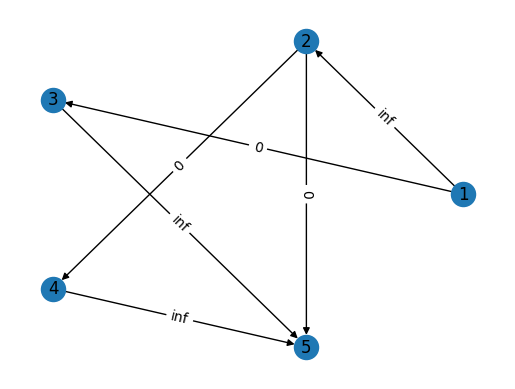

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the graph
G = nx.DiGraph()

# Add nodes
G.add_nodes_from(range(1, 6))

# Add edges
edges = [(1, 2, float('inf')), (1, 3, 0), (2, 4, 0), (2, 5, 0), (3, 5, float('inf')), (4, 5, float('inf'))]
G.add_weighted_edges_from(edges)

# Set the positions of nodes using circular layout
pos = nx.circular_layout(G)

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

# Draw edge labels (weights)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Display the graph
plt.axis('off')
plt.show()


 Functional *Part*

In [ ]:
import random
import numpy as np
import cplex
import networkx as nx
import matplotlib.pyplot as plt

def generate_st_graph(num_nodes, num_edges, weight_range=(1, 10)):
    # Generate random s-t graph with weights
    graph = nx.DiGraph()
    source = 1
    sink = num_nodes
    graph.add_node(source)  # Add source node
    graph.add_node(sink)  # Add sink node

    # Generate a connected directed acyclic graph (DAG) with random edges
    for node in range(source, sink):
        graph.add_edge(node, node+1)

    # Randomly add additional edges
    existing_edges = set(graph.edges)
    num_existing_edges = len(existing_edges)
    while num_existing_edges < num_edges: # infinite loop
        src = random.randint(source, sink-1)
        tgt = random.randint(src+1, sink)
        edge = (src, tgt)
        if edge not in existing_edges:
            graph.add_edge(src, tgt)
            existing_edges.add(edge)
            num_existing_edges += 1

    # Assign random weights to the edges
    for edge in graph.edges:
        weight = random.randint(weight_range[0], weight_range[1])
        graph[edge[0]][edge[1]]['weight'] = weight

    return graph

def generate_st_graph_simp(num_nodes, num_edges, weight_range=(1, 10)):
    # Generate random s-t graph with weights
    graph = nx.Graph()
    source = 1
    sink = num_nodes
    graph.add_node(source)  # Add source node
    graph.add_node(sink)  # Add sink node

    # Generate a connected directed acyclic graph (DAG) with random edges
    for node in range(source, sink):
        graph.add_edge(node, node+1)

    # Randomly add additional edges
    existing_edges = set(graph.edges)
    num_existing_edges = len(existing_edges)
    while num_existing_edges < num_edges:
        src = random.randint(source, sink-1)
        tgt = random.randint(src+1, sink)
        edge = (src, tgt)
        if edge not in existing_edges:
            graph.add_edge(src, tgt)
            existing_edges.add(edge)
            num_existing_edges += 1

    # Assign random weights to the edges
    for edge in graph.edges:
        weight = random.randint(weight_range[0], weight_range[1])
        graph[edge[0]][edge[1]]['weight'] = weight

    return graph

def generate_agents(num_nodes, num_agents):
    # Generate a subset of nodes as agents
    agents = random.sample(range(2, num_nodes), num_agents)  # Exclude the source and sink nodes
    return agents

def save_graph_instance(graph, agents, filepath):
    with open(filepath, 'w') as file:
        file.write("Source: 1\n")
        file.write(f"Sink: {num_nodes}\n")
        file.write("\nEdges:\n")
        for edge in graph.edges:
            file.write(f'{edge[0]} {edge[1]} {graph[edge[0]][edge[1]]["weight"]}\n')

        file.write("\nAgents:\n")
        for agent in agents:
            file.write(f'{agent}\n')

def display_agents(graph, agents):
    # Display which nodes are agents
    print("Agents:")
    for node in graph.nodes:
        if node in agents:
            print(f"Node {node} is an agent.")

def display_adjacency_matrix(graph):
    # Display the graph adjacency matrix
    adjacency_matrix = nx.to_numpy_array(graph)
    print("Adjacency Matrix:")
    print(adjacency_matrix)

def load_graph_instance(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

        # Extract the number of nodes
        num_nodes = int(lines[1].split()[1])

        # Find the line index where the edges start
        start_index = lines.index("Edges:\n") + 1

        # Extract the edges from the lines
        edges = []
        for line in lines[start_index:]:
            if line == "\n":
                break
            u, v, weight = map(int, line.split())
            edges.append((u, v, weight))

        # Find the line index where the agents start
        agents_start_index = lines.index("Agents:\n") + 1

        # Extract the agents from the lines
        agents = []
        for line in lines[agents_start_index:]:
            if line == "\n":
                break
            agent = int(line)
            agents.append(agent)

        return num_nodes, edges, agents

def add_new_edges(num_nodes, edges, agents):
    print(num_nodes)
    print(edges)
    print(agents)
    existing_edges = {(u, v) for u, v, _ in edges}
    print(existing_edges)
    new_edges = []

    for agent in agents:
        for node in range(1, num_nodes + 1):
          if (node != agent):
            if (agent, node) in existing_edges and (node, agent) not in existing_edges:
                new_edges.append((node, agent, 0))
            if (agent, node) not in existing_edges and (node, agent) in existing_edges:
                new_edges.append((agent, node, 0))
            if (agent, node) not in existing_edges and (node, agent) not in existing_edges:
                new_edges.append((agent, node, 0))
                new_edges.append((node, agent, 0))

    return edges + new_edges

def draw_graph(graph,num_nodes,agents):
  pos = nx.spring_layout(graph)
  node_colors = ['yellow' if node == 1 else 'blue' if node == num_nodes else 'red' if node in agents else 'gray' for node in graph.nodes]
  edge_labels = nx.get_edge_attributes(graph, 'weight')
  nx.draw(graph, pos, with_labels=True, node_color=node_colors)
  nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
  plt.show()

def to_dict(g):
  return  {node: list(graph[node]) for node in graph}
def to_graph(d):
  g = nx.Graph()
  g.add_nodes_from(d.keys())
  for k, v in d.items():
    g.add_edges_from(([(k, t) for t in v]))
  return g


Enter the number of nodes: 6
Enter the number of edges: 9
Enter the weight range (min max): 1 3
Enter the number of agents: 1
Graph instance saved to 'stgraph_instance.dat'.
Agents:
Node 2 is an agent.
Adjacency Matrix:
[[0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 2. 1.]
 [0. 3. 0. 0. 0. 1.]
 [0. 3. 0. 0. 0. 0.]]


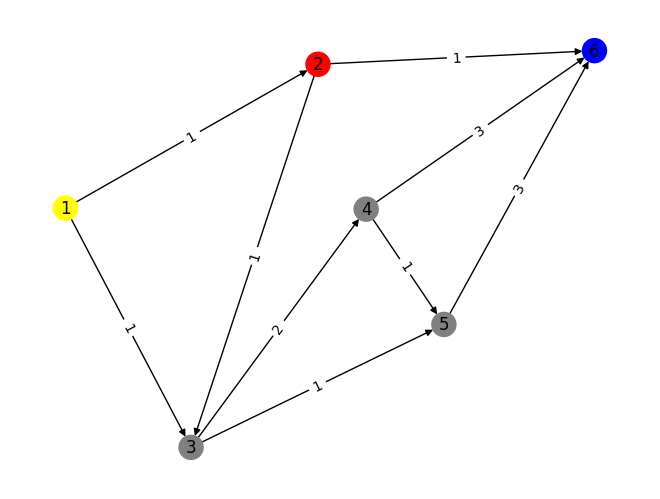

In [ ]:

# Get user inputs
num_nodes = int(input("Enter the number of nodes: "))
num_edges = int(input("Enter the number of edges: "))
weight_range = tuple(map(int, input("Enter the weight range (min max): ").split()))
num_agents = int(input("Enter the number of agents: "))

# Generate graph and agents
# graph = generate_st_graph_simp(num_nodes, num_edges, weight_range)
graph = generate_st_graph(num_nodes, num_edges, weight_range)
agents = generate_agents(num_nodes, num_agents)

# Save the graph instance to a .dat file
filepath = 'stgraph_instance.dat'
save_graph_instance(graph, agents, filepath)

print(f"Graph instance saved to '{filepath}'.")

# Display agents and adjacency matrix
display_agents(graph, agents)
display_adjacency_matrix(graph)

draw_graph(graph,num_nodes,agents)

In [ ]:
# d = to_dict(graph)
# graph = to_graph(d)
# draw_graph(graph)

In [ ]:
import cplex


# Define the LP model
def create_lp_model(num_nodes, edges):
    model = cplex.Cplex()
    model.set_problem_name("MinCutLP")

    # Decision variables
    d = model.variables.add(names=["d_{}_{}".format(u, v) for u, v, _ in edges], types=[model.variables.type.binary] * len(edges))
    p = model.variables.add(names=["p_{}".format(u) for u in range(1, num_nodes+1)], types=[model.variables.type.binary] * num_nodes)

    # Objective function
    costs = [weight for _, _, weight in edges]
    model.objective.set_sense(model.objective.sense.minimize)
    model.objective.set_linear([(d[i], costs[i]) for i in range(len(edges))])

    # Constraints
    for i, (u, v, _) in enumerate(edges):
        model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=[d[i], p[u-1], p[v-1]], val=[1.0, -1.0, 1.0])], senses=["G"], rhs=[0.0])

    model.linear_constraints.add(lin_expr=[[[p[0]], [1.0]]], senses=["E"], rhs=[1.0])
    model.linear_constraints.add(lin_expr=[[[p[num_nodes-1]], [1.0]]], senses=["E"], rhs=[0.0])

    return model

def create_lp_model_agent(num_nodes, edges, new, agents):
    model = cplex.Cplex()
    model.set_problem_name("MinCutLP")

    # Decision variables
    d = model.variables.add(names=["d_{}_{}".format(u, v) for u, v, _ in edges], types=[model.variables.type.binary] * len(edges))
    p = model.variables.add(names=["p_{}".format(u) for u in range(1, num_nodes+1)], types=[model.variables.type.binary] * num_nodes)
    k = model.variables.add(names=["k_{}_{}".format(u, v) for u, v, _ in new], types=[model.variables.type.binary] * len(new))
    # Objective function
    costs = [weight for _, _, weight in edges]
    model.objective.set_sense(model.objective.sense.minimize)
    model.objective.set_linear([(d[i], costs[i]) for i in range(len(edges))])

    # Constraints
    for i, (u, v, _) in enumerate(edges):
        model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=[d[i], p[u-1], p[v-1]], val=[1.0, -1.0, 1.0])], senses=["G"], rhs=[0.0])

    for i, (u, v, _) in enumerate(new):
        model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=[k[i], p[u-1], p[v-1]], val=[1.0, -1.0, 1.0])], senses=["G"], rhs=[0.0])

    model.linear_constraints.add(lin_expr=[[[p[0]], [1.0]]], senses=["E"], rhs=[1.0])
    model.linear_constraints.add(lin_expr=[[[p[num_nodes-1]], [1.0]]], senses=["E"], rhs=[0.0])

    # # Additional constraints for outgoing edges of agents
    # # Constraint for agent outgoing edges
    for agent in agents:
      lin_expr = [k[i] for i, (u, v, _) in enumerate(new) if u == agent]
      model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=lin_expr,val=[1.0]*len(lin_expr))], senses=["L"], rhs=[num_nodes / 2])

    # # Constraint for agent incoming edges
    for agent in agents:
      lin_expr = [k[i] for i, (u, v, _) in enumerate(new) if v == agent]
      model.linear_constraints.add(lin_expr=[cplex.SparsePair(ind=lin_expr,val=[1.0]*len(lin_expr))], senses=["L"], rhs=[num_nodes / 2])

    return model

# Solve the LP model
def solve_lp_model(model, edges):
    model.solve()

    # Get solution
    solution = model.solution

    # Print solution
    print("Solution status:", solution.get_status())
    print("Objective value:", solution.get_objective_value())
    print("Cut edges:")
    cuts = []

    for i in range(len(edges)):
        if abs(solution.get_values("p_{}".format(edges[i][0])) - solution.get_values("p_{}".format(edges[i][1])))>0:
            print("Edge ({}, {})".format(edges[i][0], edges[i][1]))
            cuts.append((edges[i][0],edges[i][1]))
    return  solution, cuts

In [ ]:
# Load graph instance from the .dat file
def load_graph_instance2(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()

        # Extract the number of nodes
        num_nodes = int(lines[1].split()[1])

        # Find the line index where the edges start
        start_index = lines.index("Edges:\n") + 1

        # Extract the edges from the lines
        edges = []
        for line in lines[start_index:]:
            if line == "\n":
                break
            u, v, weight = map(int, line.split())
            edges.append((u, v, weight))

        return num_nodes, edges

# Load graph instance from the .dat file
num_nodes, edges = load_graph_instance2("stgraph_instance.dat")
print(load_graph_instance("stgraph_instance.dat"))
# Create the LP model
model = create_lp_model(num_nodes, edges)

# Solve the LP model
sol, cuts = solve_lp_model(model, edges)

(6, [(1, 2, 1), (1, 3, 1), (2, 3, 1), (2, 6, 1), (3, 4, 2), (3, 5, 1), (4, 5, 1), (4, 6, 3), (5, 6, 3)], [2])
Version identifier: 22.1.1.0 | 2023-02-11 | 22d6266e5
CPXPARAM_Read_DataCheck                          1
Tried aggregator 2 times.
MIP Presolve eliminated 7 rows and 10 columns.
Aggregator did 4 substitutions.
All rows and columns eliminated.
Presolve time = 0.00 sec. (0.02 ticks)

Root node processing (before b&c):
  Real time             =    0.01 sec. (0.02 ticks)
Parallel b&c, 2 threads:
  Real time             =    0.00 sec. (0.00 ticks)
  Sync time (average)   =    0.00 sec.
  Wait time (average)   =    0.00 sec.
                          ------------
Total (root+branch&cut) =    0.01 sec. (0.02 ticks)
Solution status: 101
Objective value: 2.0
Cut edges:
Edge (1, 2)
Edge (1, 3)


In [ ]:
edges

In [ ]:
cuts

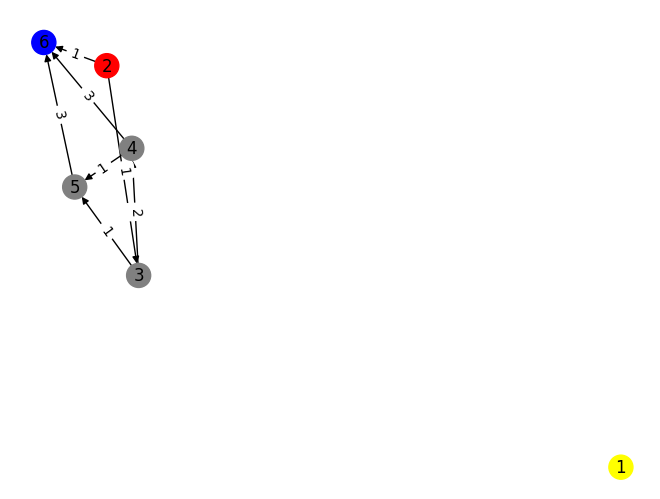

In [ ]:
gr = graph.copy()
for c in cuts:
  gr.remove_edge(c[0],c[1])
draw_graph(gr,num_nodes,agents)

In [ ]:
su = 0
for i in range(len(edges)):
  print(edges[i][0], edges[i][1])
  print(sol.get_values("p_{}".format(edges[i][0])) - sol.get_values("p_{}".format(edges[i][1])))
  print(sol.get_values("d_{}_{}".format(edges[i][0], edges[i][1])))
  print()
  su += int(sol.get_values("d_{}_{}".format(edges[i][0], edges[i][1]))) * edges[i][2]

In [ ]:
su

In [ ]:
for _, _, weight in edges:
  print(weight)

In [ ]:
for i in range(num_nodes):
  print(sol.get_values("p_{}".format(i+1)))

1.0
0.0
0.0
0.0
0.0
0.0


In [ ]:
# Example usage
num_nodes, edges, agents = load_graph_instance("stgraph_instance.dat")

new_edges = add_new_edges(num_nodes, edges, agents)
print("Updated edges:", new_edges)

# Create the LP model
# model = create_lp_model(num_nodes, edges)
model = create_lp_model_agent(num_nodes, edges, new_edges,agents)


# Solve the LP model
sol, cuts = solve_lp_model(model, edges)

6
[(1, 2, 1), (1, 3, 1), (2, 3, 1), (2, 6, 1), (3, 4, 2), (3, 5, 1), (4, 5, 1), (4, 6, 3), (5, 6, 3)]
[2]
{(1, 2), (3, 4), (4, 6), (2, 3), (4, 5), (2, 6), (5, 6), (1, 3), (3, 5)}
Updated edges: [(1, 2, 1), (1, 3, 1), (2, 3, 1), (2, 6, 1), (3, 4, 2), (3, 5, 1), (4, 5, 1), (4, 6, 3), (5, 6, 3), (2, 1, 0), (3, 2, 0), (2, 4, 0), (4, 2, 0), (2, 5, 0), (5, 2, 0), (6, 2, 0)]
Version identifier: 22.1.1.0 | 2023-02-11 | 22d6266e5
CPXPARAM_Read_DataCheck                          1
Tried aggregator 2 times.
MIP Presolve eliminated 11 rows and 10 columns.
Aggregator did 6 substitutions.
Reduced MIP has 12 rows, 14 columns, and 38 nonzeros.
Reduced MIP has 14 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.01 sec. (0.05 ticks)
Found incumbent of value 2.000000 after 0.01 sec. (0.06 ticks)
Probing time = 0.00 sec. (0.00 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 12 rows, 14 columns, and 38 nonzeros.
Reduced MIP has 14 binaries, 0 generals, 0 SOSs, and 0

In [ ]:
agents

[2]

In [ ]:
for i in range(len(new_edges)):
  print(new_edges[i][0], new_edges[i][1])
  print(sol.get_values("p_{}".format(new_edges[i][0])) - sol.get_values("p_{}".format(new_edges[i][1])))
  print(sol.get_values("k_{}_{}".format(new_edges[i][0], new_edges[i][1])))
  print()

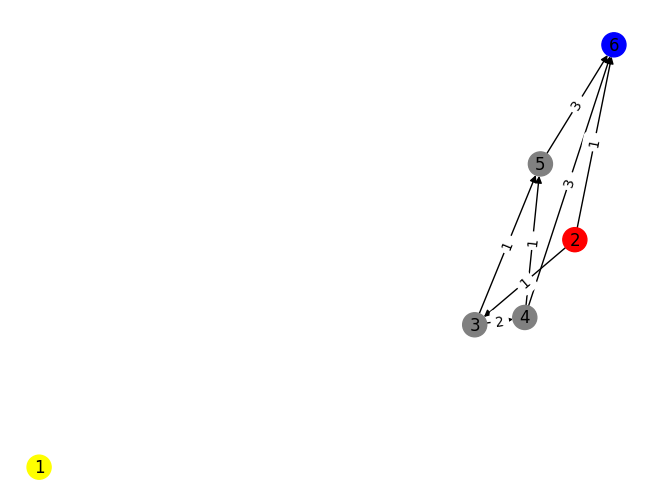

In [ ]:
gr = graph.copy()
for c in cuts:
  gr.remove_edge(c[0],c[1])
draw_graph(gr,num_nodes,agents)

6
[(1, 2, 3), (1, 3, 2), (2, 5, 2), (3, 2, 3), (3, 4, 3), (4, 6, 2), (5, 3, 1), (5, 4, 3), (5, 6, 3)]
[2, 3, 5]
{(1, 2), (3, 4), (5, 4), (4, 6), (5, 6), (5, 3), (3, 2), (2, 5), (1, 3)}
Version identifier: 22.1.1.0 | 2023-02-11 | 22d6266e5
CPXPARAM_Read_DataCheck                          1
Tried aggregator 3 times.
MIP Presolve eliminated 7 rows and 11 columns.
MIP Presolve added 1 rows and 1 columns.
Aggregator did 5 substitutions.
All rows and columns eliminated.
Presolve time = 0.01 sec. (0.02 ticks)

Root node processing (before b&c):
  Real time             =    0.01 sec. (0.03 ticks)
Parallel b&c, 2 threads:
  Real time             =    0.00 sec. (0.00 ticks)
  Sync time (average)   =    0.00 sec.
  Wait time (average)   =    0.00 sec.
                          ------------
Total (root+branch&cut) =    0.01 sec. (0.03 ticks)
Solution status: 101
Objective value: 4.0
Cut edges:
Edge (1, 3)
Edge (2, 5)
Edge (3, 2)


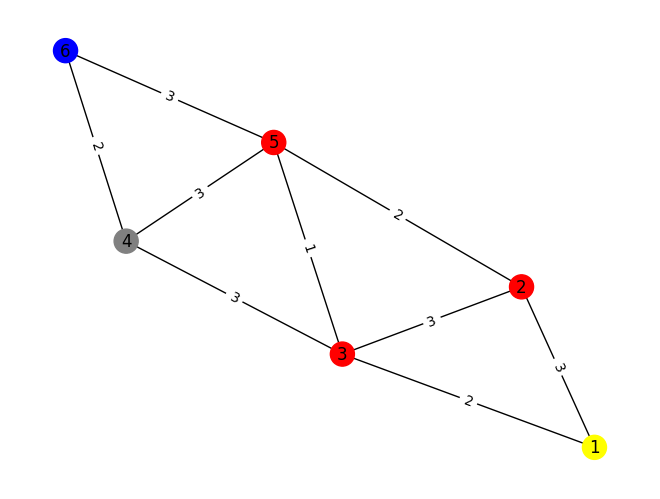

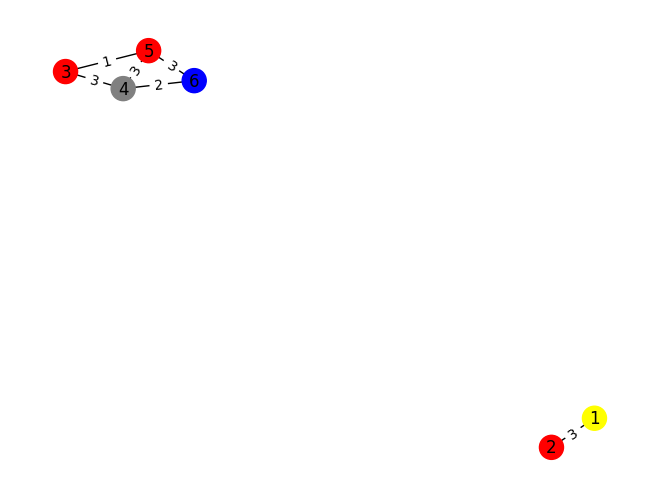

In [ ]:
def graph_from_edges(n,edg):
    graph = nx.Graph()
    source = 1
    sink = n
    graph.add_node(source)  # Add source node
    graph.add_node(sink)
    for e in edg:
      graph.add_edge(e[0], e[1])
      graph[e[0]][e[1]]['weight'] = e[2]
    return  graph


a = [2,3,5]
n = 6
edg = [(1,2,3),(1,3,2),(2,5,2),(3,2,3),(3,4,3),(4,6,2),(5,3,1),(5,4,3),(5,6,3)]

#a = [2]
#n = 6
#edg = [(1,2,3),(1,3,2),(2,5,2),(3,2,3),(3,4,3),(4,6,2),(5,3,1),(5,4,3),(5,6,3)]

nw = add_new_edges(n, edg, a)

man = graph_from_edges(n,edg)

#model = create_lp_model_agent(n, edg, nw,a)
model = create_lp_model(n, edg)
sol, cuts = solve_lp_model(model, edg)

gr = man.copy()
draw_graph(gr,n,a)
for c in cuts:
  gr.remove_edge(c[0],c[1])
draw_graph(gr,n,a)